In [1]:
from joblib import Parallel, delayed
from tqdm.notebook import tqdm

import sys
import pickle
import numpy as np
import pandas as pd
import networkx as nx
import scipy
from itertools import combinations

sys.path.insert(0, "src")

from grn import grn


In [2]:
import numpy as np
import pandas as pd
import torch
from torch import nn
import torch.optim as optim
import time
import copy
from itertools import combinations
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
from sklearn.linear_model import LinearRegression

# ============================================================
# INITIALIZE GLOBAL STORAGE
# ============================================================
all_results = []
higher_order_results = [] # New list to store our high-order evaluations

for network_seed in range(10):
    np.random.seed(network_seed)

    # manually adjust GRN hyperparameters
    G = grn().add_structure(
        n=256,
        k=1,
        alpha=1e-99,
        beta=0.75,       # 1 - 1/r
        gamma=0.25,      # 1/r
        kappa=10,        # --w
        delta_in=100,
        delta_out=1,
    )

    G.simulate_rna(
        s=1e-4,
        dt=1e-2,
        tmax=20000,
        burnin=5000,
        tol=1e-3,
        save=True,
    )

    x_wt = np.zeros(256)
    y_wt = G.rna

    single_ko_expression = np.zeros((G.n, G.n))
    single_ko_logfc = np.zeros((G.n, G.n))
    single_ko_convergence = {}

    for gene in tqdm(range(G.n), desc=f"Network {network_seed}: single-gene KOs"):
        result = G.ko_nodes(
            genes=[gene],
            stats=("new_rna", "logfc", "convergence"),
            s=1e-4,
            dt=1e-2,
            tmax=20000,
            burnin=5000,
            tol=1e-3,
        )

        single_ko_expression[gene, :] = result["new_rna"].flatten()
        single_ko_logfc[gene, :] = result["logfc"].flatten()
        single_ko_convergence[gene] = result["convergence"]

    x_single_ko = np.eye(G.n)
    y_single_ko = single_ko_expression
    
    # ------------------------------------------------------------
    # DOUBLE KO SIMULATION
    # ------------------------------------------------------------
    pairs = list(combinations(range(G.n), 2))

    def run_double_ko(pair):
        a, b = pair
        result = G.ko_nodes(
            genes=[a, b],
            stats=("new_rna", "logfc", "convergence"),
            s=1e-4, dt=1e-2, tmax=20000, burnin=5000, tol=1e-3,
        )
        return (
            np.asarray(result["new_rna"]).flatten(),
            np.asarray(result["logfc"]).flatten(),
            np.asarray(result["convergence"]),
        )

    results = Parallel(n_jobs=64, pre_dispatch="n_jobs", prefer="processes", verbose=0)(
        delayed(run_double_ko)(pair) for pair in pairs
    )

    double_expression = np.asarray([r[0] for r in results], dtype=np.float32)

    # prepare as training data
    pairs = np.array(pairs, dtype=np.int32)
    x_double_ko = np.zeros((pairs.shape[0], G.n))
    rows = np.arange(pairs.shape[0])
    x_double_ko[rows, pairs[:, 0]] = 1.0
    x_double_ko[rows, pairs[:, 1]] = 1.0
    y_double_ko = double_expression

    # ------------------------------------------------------------
    # HIGHER ORDER KO SIMULATION (Sets 3 to 10)
    # ------------------------------------------------------------
    select_size = 200
    higher_expression = {}
    all_select_sets = []
    X_list = []

    for set_size in tqdm(range(3, 11), desc=f"Network {network_seed}: higher-order KOs"):
        select_sets = set()
        while len(select_sets) < select_size:
            comb = tuple(sorted(np.random.choice(G.n, size=set_size, replace=False)))
            select_sets.add(comb)
        select_sets = list(select_sets)

        def run_combination_ko(comb):
            res = G.ko_nodes(genes=list(comb), stats=("new_rna",), s=1e-4, dt=1e-2, tmax=20000, burnin=5000, tol=1e-3)
            return np.asarray(res["new_rna"]).flatten()

        results_ho = Parallel(n_jobs=64, prefer="processes")(
            delayed(run_combination_ko)(combination) for combination in select_sets
        )

        higher_expression[set_size] = np.asarray(results_ho, dtype=np.float32)
        
        select_sets_arr = np.array(select_sets, dtype=np.int32)
        all_select_sets.append(select_sets_arr)

        X_subset = np.zeros((select_size, G.n), dtype=np.float32)
        rows_ho = np.arange(select_size)[:, None]
        X_subset[rows_ho, select_sets_arr] = 1.0
        X_list.append(X_subset)


    # ============================================================
    # 3 TRAINING RUNS ON THIS GRN
    # ============================================================
    for training_seed in range(3):
        torch.manual_seed(training_seed)
        device = torch.device("cpu")

        model = nn.Sequential(
            nn.Linear(256, 512), nn.GELU(),
            nn.Linear(512, 512), nn.GELU(),
            nn.Linear(512, 256)
        ).to(device)

        optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)

        # process data
        rng = np.random.default_rng(training_seed)
        n_pairs = pairs.shape[0]
        nt, nv = int(0.5 * n_pairs), int(0.1 * n_pairs)
        indices = rng.permutation(n_pairs)
        
        test_idx = indices[:nt]
        val_idx = indices[nt:nt + nv]
        train_idx = indices[nt + nv:]

        xtr = np.concatenate([x_wt[None, :], x_single_ko, x_double_ko[train_idx]], axis=0)
        ytr = np.concatenate([y_wt[None, :], y_single_ko, y_double_ko[train_idx]], axis=0)
        xv = x_double_ko[val_idx]
        yv = y_double_ko[val_idx]
        x_test = x_double_ko[test_idx]
        y_test = y_double_ko[test_idx]

        mean = np.mean(ytr, axis=0)
        scale = np.maximum(ytr.std(axis=0), 1e-6)
        s_ytr = (ytr - mean) / scale

        xtr_t = torch.as_tensor(xtr, dtype=torch.float32, device=device)
        s_ytr_t = torch.as_tensor(s_ytr, dtype=torch.float32, device=device)
        xv_t = torch.as_tensor(xv, dtype=torch.float32, device=device)

        # Training loop
        max_epochs = 300
        batch_size = 256
        lr = 1e-3
        patience = 40
        min_lr = 1e-5
        lr_patience = 12

        best, best_epoch, stale, lr_stale = np.inf, 0, 0, 0
        best_model_weights = None

        for epoch in range(1, max_epochs + 1):
            model.train()
            permutation = torch.randperm(xtr_t.shape[0], device=device)
            for start in range(0, xtr_t.shape[0], batch_size):
                ii = permutation[start:(start + batch_size)]
                optimizer.zero_grad(set_to_none=True)
                loss = torch.mean((model(xtr_t[ii]) - s_ytr_t[ii]) ** 2)
                loss.backward()
                optimizer.step()

            model.eval()
            with torch.inference_mode():
                val_scaled = torch.cat([model(chunk) for chunk in xv_t.split(1024)]).cpu().numpy()
            
            val_pred = val_scaled.astype(np.float32) * scale + mean
            raw_mse = float(np.mean((val_pred - yv) ** 2))

            if raw_mse < best:
                best = raw_mse
                stale = 0
                lr_stale = 0
                best_model_weights = copy.deepcopy(model.state_dict())
            else:
                stale += 1
                lr_stale += 1

            if lr_stale >= lr_patience and lr > min_lr:
                lr = max(min_lr, lr * .5)
                for group in optimizer.param_groups:
                    group["lr"] = lr
                lr_stale = 0

            if stale >= patience:
                break

        if best_model_weights is not None:
            model.load_state_dict(best_model_weights)

        # Fit Baseline Linear Model
        linear_model = LinearRegression(fit_intercept=True)
        linear_model.fit(xtr.astype(np.float64), s_ytr.astype(np.float64))

        # ------------------------------------------------------------
        # EVALUATE ON HIGHER ORDER DATASETS
        # ------------------------------------------------------------
        model.eval()
        for i, set_size in enumerate(range(3, 11)):
            X_subset = X_list[i]
            select_sets_arr = all_select_sets[i]
            y_true = higher_expression[set_size]
            
            # Additive Baseline for k-gene KO
            additive = y_single_ko[select_sets_arr].sum(axis=1) - (set_size - 1) * y_wt
            
            # Linear model eval
            lin_scaled = linear_model.predict(X_subset.astype(np.float64))
            lin_pred = lin_scaled.astype(np.float32) * scale + mean
            
            # MLP eval
            X_subset_t = torch.as_tensor(X_subset, dtype=torch.float32, device=device)
            with torch.inference_mode():
                mlp_scaled = torch.cat([model(chunk) for chunk in X_subset_t.split(1024)]).cpu().numpy()
            mlp_pred = mlp_scaled.astype(np.float32) * scale + mean
            
            # Calculate MSE
            add_mse = float(np.mean((additive - y_true) ** 2))
            lin_mse = float(np.mean((lin_pred - y_true) ** 2))
            mlp_mse = float(np.mean((mlp_pred - y_true) ** 2))
            
            # Calc percentage improvement over additive
            lin_improv = 100 * (1 - lin_mse / add_mse)
            mlp_improv = 100 * (1 - mlp_mse / add_mse)
            
            higher_order_results.append({
                "Network Seed": network_seed,
                "Training Seed": training_seed,
                "Combination Size (k)": set_size,
                "Linear Improv (%)": lin_improv,
                "MLP Improv (%)": mlp_improv
            })

# ================================================================
# FINAL RESULT TABLES
# ================================================================

# Convert higher order metrics into DataFrame
ho_df = pd.DataFrame(higher_order_results)

# Helper function to format triplicate values as a list string
def format_triplicate(series):
    return "[" + ", ".join([f"{val:.1f}%" for val in series.values]) + "]"

# Group by Combination Size & Network Seed, applying the formatting function to aggregate 3 training runs
ho_aggregated = ho_df.groupby(["Combination Size (k)", "Network Seed"]).agg({
    "Linear Improv (%)": format_triplicate,
    "MLP Improv (%)": format_triplicate
}).reset_index()

# Pivot for Final Display
pivot_lin = ho_aggregated.pivot(index="Combination Size (k)", columns="Network Seed", values="Linear Improv (%)")
pivot_mlp = ho_aggregated.pivot(index="Combination Size (k)", columns="Network Seed", values="MLP Improv (%)")

pivot_lin.columns.name = "GRN Random Seed"
pivot_mlp.columns.name = "GRN Random Seed"

print("\n=== Linear Model: MSE Improvement over Additive Baseline (Triplicates) ===")
display(pivot_lin)

print("\n=== MLP Model: MSE Improvement over Additive Baseline (Triplicates) ===")
display(pivot_mlp)

Network 0: single-gene KOs:   0%|          | 0/256 [00:00<?, ?it/s]

Network 0: higher-order KOs:   0%|          | 0/8 [00:00<?, ?it/s]

Network 1: single-gene KOs:   0%|          | 0/256 [00:00<?, ?it/s]

Network 1: higher-order KOs:   0%|          | 0/8 [00:00<?, ?it/s]

Network 2: single-gene KOs:   0%|          | 0/256 [00:00<?, ?it/s]

...

Network 9: higher-order KOs:   0%|          | 0/8 [00:00<?, ?it/s]


=== Linear Model: MSE Improvement over Additive Baseline (Triplicates) ===


GRN Random Seed,0,1,2,3,4,5,6,7,8,9
Combination Size (k),,,,,,,,,,
3,"[-12.2%, 1.9%, -0.5%]","[0.1%, 2.5%, -1.4%]","[-5.1%, -4.6%, -1.1%]","[-0.0%, 0.9%, 3.1%]","[4.4%, 1.0%, 2.2%]","[7.8%, 5.7%, 6.7%]","[6.9%, 6.4%, 6.3%]","[-0.1%, -0.4%, 0.9%]","[13.8%, 13.5%, 8.1%]","[6.4%, 4.4%, 0.4%]"
4,"[-1.5%, 4.4%, -0.7%]","[1.4%, 2.2%, 4.4%]","[0.9%, 0.6%, -0.1%]","[0.5%, 1.6%, 0.3%]","[5.7%, 4.0%, 2.9%]","[-0.1%, 6.4%, 7.2%]","[6.2%, 5.5%, 7.4%]","[1.8%, 2.3%, -0.4%]","[-2.6%, -0.9%, -2.0%]","[1.8%, 2.0%, 2.2%]"
5,"[-3.7%, 2.8%, 0.1%]","[3.5%, 2.8%, 8.0%]","[2.5%, 3.2%, 0.9%]","[1.0%, 1.4%, 0.7%]","[-2.5%, -0.5%, -3.2%]","[5.1%, 6.5%, 8.1%]","[6.1%, 4.7%, 5.1%]","[3.9%, 2.1%, 3.5%]","[11.4%, 14.1%, 9.1%]","[1.5%, 4.2%, 6.0%]"
6,"[4.9%, 0.9%, 2.0%]","[3.8%, 1.3%, 1.2%]","[1.6%, 3.2%, 1.1%]","[0.3%, 3.9%, 0.3%]","[-0.5%, 2.0%, 2.2%]","[6.1%, 7.0%, 6.9%]","[5.9%, 4.8%, 5.8%]","[-1.7%, 0.4%, -0.1%]","[9.7%, 9.9%, 6.5%]","[5.1%, 1.1%, 2.7%]"
7,"[3.5%, 2.4%, 2.7%]","[2.5%, 2.6%, 3.0%]","[1.1%, 2.1%, -0.4%]","[0.7%, 2.0%, 1.7%]","[2.3%, 3.8%, 3.1%]","[5.3%, 6.8%, 6.7%]","[7.8%, 4.5%, 6.7%]","[4.9%, 3.1%, 3.6%]","[8.4%, 10.2%, 7.3%]","[5.1%, 1.4%, 4.0%]"
8,"[2.7%, 3.0%, 3.3%]","[4.3%, 2.6%, 4.4%]","[1.4%, 1.7%, 0.9%]","[1.3%, 0.8%, 1.6%]","[-0.4%, -0.1%, -1.9%]","[6.6%, 7.1%, 5.6%]","[5.7%, 4.0%, 5.1%]","[3.2%, 1.5%, 1.1%]","[11.9%, 13.4%, 10.1%]","[4.6%, 1.5%, 3.3%]"
9,"[0.9%, 1.3%, 0.7%]","[4.5%, 4.3%, 6.0%]","[2.2%, 1.8%, 2.1%]","[0.9%, 2.4%, 0.1%]","[2.6%, 3.4%, 2.2%]","[7.6%, 6.5%, 5.2%]","[5.9%, 4.4%, 4.6%]","[0.7%, 2.5%, 1.6%]","[10.1%, 11.0%, 6.4%]","[3.4%, 3.0%, 3.8%]"
10,"[5.8%, 2.2%, 4.3%]","[3.8%, 2.6%, 4.4%]","[1.6%, 1.6%, 1.5%]","[1.8%, 1.7%, 2.2%]","[3.4%, 2.7%, 3.1%]","[5.1%, 5.0%, 6.1%]","[6.8%, 5.4%, 7.1%]","[3.3%, 1.5%, 2.0%]","[12.7%, 13.6%, 8.6%]","[2.9%, 2.7%, 4.4%]"



=== MLP Model: MSE Improvement over Additive Baseline (Triplicates) ===


GRN Random Seed,0,1,2,3,4,5,6,7,8,9
Combination Size (k),,,,,,,,,,
3,"[-7.9%, 35.7%, 15.6%]","[56.5%, 53.0%, -5.0%]","[-14.7%, 12.9%, -32.1%]","[-6.5%, 31.7%, 23.5%]","[86.7%, 75.3%, 31.4%]","[75.7%, 58.3%, 67.8%]","[66.5%, 83.9%, 66.7%]","[-24.4%, -5.1%, 80.1%]","[96.2%, 5.0%, -88.6%]","[47.6%, 60.0%, 63.5%]"
4,"[11.0%, 42.9%, -20.6%]","[30.6%, 34.9%, -6.0%]","[-6.7%, -33.4%, -23.5%]","[-17.3%, 31.4%, 23.6%]","[46.4%, 60.9%, 13.6%]","[51.7%, 59.4%, 79.0%]","[43.4%, 55.2%, 70.5%]","[85.0%, 54.1%, 51.6%]","[42.9%, 62.9%, 78.0%]","[39.3%, 39.0%, 50.9%]"
5,"[-16.7%, -64.3%, -21.6%]","[-42.0%, -60.1%, 70.0%]","[35.4%, 27.9%, -4.0%]","[-29.8%, 18.6%, 13.3%]","[-16.9%, 6.8%, -25.6%]","[82.0%, 72.1%, 78.4%]","[64.2%, 38.1%, 44.5%]","[-31.0%, -23.7%, -4.7%]","[86.9%, 88.2%, 92.4%]","[53.9%, 75.1%, 73.7%]"
6,"[76.8%, 24.1%, 15.7%]","[39.0%, -22.4%, -21.2%]","[19.9%, 1.7%, 0.0%]","[-38.2%, 41.8%, -26.3%]","[-1.9%, 28.4%, 24.7%]","[61.5%, 74.0%, 62.2%]","[50.1%, 44.4%, 45.0%]","[10.0%, 33.7%, 23.8%]","[74.3%, 48.0%, 19.2%]","[82.3%, 75.9%, 62.5%]"
7,"[29.4%, -51.4%, 36.1%]","[6.6%, -58.4%, 12.9%]","[-26.5%, -13.7%, -55.2%]","[-20.4%, -15.7%, 5.8%]","[27.6%, 58.8%, 50.7%]","[52.8%, 74.4%, 64.7%]","[75.5%, 34.7%, 55.3%]","[56.2%, 57.2%, 55.9%]","[-1.8%, 53.8%, 66.5%]","[69.3%, 59.2%, 66.8%]"
8,"[-2.3%, 14.1%, 6.4%]","[40.9%, 16.8%, 41.7%]","[-17.4%, -23.9%, -30.9%]","[-57.9%, -16.9%, -7.5%]","[23.4%, 11.5%, 8.4%]","[61.8%, 71.8%, 70.9%]","[46.2%, 36.8%, 36.3%]","[65.7%, 46.3%, 52.8%]","[54.6%, 72.1%, 81.4%]","[80.6%, 62.2%, 67.4%]"
9,"[-10.1%, 8.5%, -2.6%]","[32.0%, 18.6%, 57.5%]","[-10.5%, -45.9%, -35.1%]","[-71.3%, -7.7%, -46.1%]","[26.0%, 41.9%, 36.6%]","[60.8%, 51.9%, 62.3%]","[52.3%, 35.9%, 34.7%]","[42.1%, 40.6%, 34.7%]","[72.8%, 79.4%, 56.5%]","[37.5%, 38.2%, 50.1%]"
10,"[32.4%, 14.1%, 46.9%]","[17.2%, 5.8%, 54.6%]","[-26.4%, -39.9%, -44.1%]","[-39.0%, -4.2%, -27.4%]","[6.2%, 11.8%, 16.1%]","[51.4%, 53.6%, 68.9%]","[43.9%, 21.4%, 23.4%]","[38.9%, 47.6%, 34.7%]","[55.7%, 55.3%, 7.8%]","[46.8%, 46.6%, 64.7%]"


In [3]:
# Calculate relative MSE reduction of MLP over Linear:
# 100 * (MSE_Linear - MSE_MLP) / MSE_Linear
# Derived from existing % improvements vs Additive: 100 * (1 - (100 - MLP_Improv) / (100 - Linear_Improv))
ho_df["MLP_vs_Linear_Improv (%)"] = 100 * (
    1 - (100 - ho_df["MLP Improv (%)"]) / (100 - ho_df["Linear Improv (%)"])
)

# Aggregate triplicates across training seeds into list strings
ho_mlp_vs_lin = ho_df.groupby(["Combination Size (k)", "Network Seed"]).agg({
    "MLP_vs_Linear_Improv (%)": lambda series: "[" + ", ".join([f"{val:.1f}%" for val in series.values]) + "]"
}).reset_index()

# Pivot for Final Display (Rows = Combination Size, Columns = Network Seed)
pivot_mlp_vs_lin = ho_mlp_vs_lin.pivot(
    index="Combination Size (k)", 
    columns="Network Seed", 
    values="MLP_vs_Linear_Improv (%)"
)

pivot_mlp_vs_lin.columns.name = "GRN Random Seed"

print("\n=== MLP Model: Relative MSE Improvement over Linear Regression (Triplicates) ===")
display(pivot_mlp_vs_lin)


=== MLP Model: Relative MSE Improvement over Linear Regression (Triplicates) ===


GRN Random Seed,0,1,2,3,4,5,6,7,8,9
Combination Size (k),,,,,,,,,,
3,"[3.9%, 34.5%, 16.0%]","[56.5%, 51.8%, -3.5%]","[-9.1%, 16.7%, -30.7%]","[-6.5%, 31.1%, 21.1%]","[86.1%, 75.0%, 29.8%]","[73.6%, 55.8%, 65.5%]","[64.0%, 82.8%, 64.5%]","[-24.3%, -4.7%, 79.9%]","[95.6%, -9.8%, -105.2%]","[44.0%, 58.1%, 63.4%]"
4,"[12.3%, 40.3%, -19.7%]","[29.6%, 33.4%, -11.0%]","[-7.7%, -34.3%, -23.5%]","[-17.9%, 30.3%, 23.4%]","[43.2%, 59.3%, 11.0%]","[51.8%, 56.6%, 77.4%]","[39.6%, 52.6%, 68.2%]","[84.7%, 53.0%, 51.7%]","[44.4%, 63.2%, 78.4%]","[38.2%, 37.7%, 49.8%]"
5,"[-12.5%, -69.1%, -21.8%]","[-47.1%, -64.6%, 67.3%]","[33.7%, 25.5%, -4.9%]","[-31.1%, 17.5%, 12.7%]","[-14.1%, 7.3%, -21.7%]","[81.0%, 70.2%, 76.5%]","[61.8%, 35.1%, 41.5%]","[-36.3%, -26.4%, -8.5%]","[85.2%, 86.3%, 91.7%]","[53.2%, 74.0%, 72.0%]"
6,"[75.6%, 23.4%, 14.0%]","[36.6%, -24.0%, -22.7%]","[18.5%, -1.6%, -1.1%]","[-38.5%, 39.4%, -26.6%]","[-1.3%, 27.0%, 23.0%]","[59.0%, 72.0%, 59.4%]","[47.0%, 41.6%, 41.6%]","[11.5%, 33.4%, 23.9%]","[71.5%, 42.3%, 13.6%]","[81.3%, 75.6%, 61.4%]"
7,"[26.9%, -55.0%, 34.4%]","[4.2%, -62.6%, 10.2%]","[-27.9%, -16.2%, -54.7%]","[-21.2%, -18.0%, 4.2%]","[25.9%, 57.2%, 49.1%]","[50.2%, 72.6%, 62.1%]","[73.4%, 31.7%, 52.1%]","[53.9%, 55.9%, 54.2%]","[-11.1%, 48.6%, 63.8%]","[67.7%, 58.6%, 65.5%]"
8,"[-5.1%, 11.4%, 3.2%]","[38.2%, 14.7%, 39.0%]","[-19.0%, -26.1%, -32.1%]","[-60.0%, -17.9%, -9.2%]","[23.7%, 11.6%, 10.1%]","[59.1%, 69.6%, 69.2%]","[43.0%, 34.1%, 32.9%]","[64.6%, 45.5%, 52.3%]","[48.4%, 67.8%, 79.3%]","[79.6%, 61.6%, 66.3%]"
9,"[-11.1%, 7.2%, -3.3%]","[28.8%, 15.0%, 54.7%]","[-13.0%, -48.6%, -38.0%]","[-72.8%, -10.3%, -46.2%]","[24.0%, 39.8%, 35.2%]","[57.6%, 48.5%, 60.2%]","[49.3%, 32.9%, 31.5%]","[41.7%, 39.1%, 33.7%]","[69.7%, 76.9%, 53.6%]","[35.3%, 36.2%, 48.1%]"
10,"[28.2%, 12.2%, 44.5%]","[14.0%, 3.3%, 52.5%]","[-28.4%, -42.2%, -46.3%]","[-41.6%, -6.0%, -30.3%]","[2.9%, 9.4%, 13.4%]","[48.8%, 51.1%, 66.8%]","[39.9%, 16.9%, 17.6%]","[36.8%, 46.8%, 33.4%]","[49.2%, 48.3%, -0.9%]","[45.2%, 45.2%, 63.1%]"


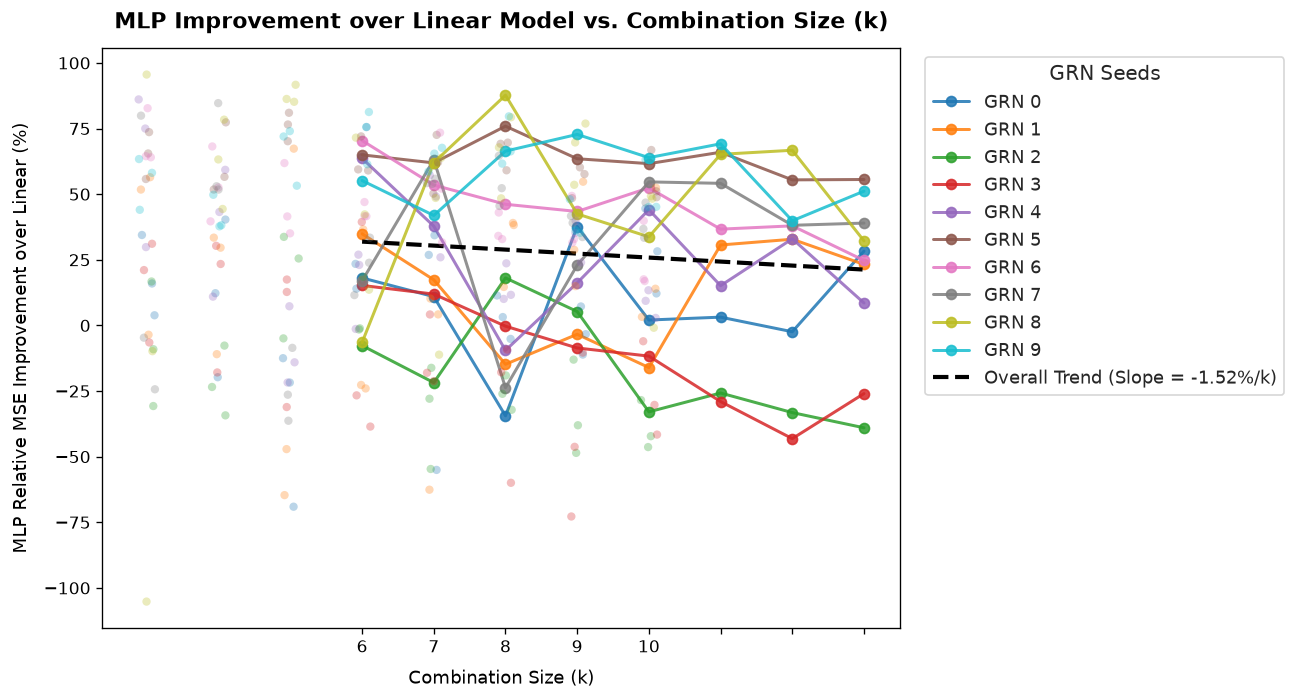

=== OVERALL TREND METRICS (Across all GRNs) ===
• Linear Trend Slope : -1.522% decrease per unit increase in k
• Pearson Correlation: r = -0.106
• Statistical Sig.  : p = 3.4903e-01

=== PER-GRN TREND BREAKDOWN ===


,GRN Seed,Slope (% per Δk),Pearson r,p-value,Decreasing?
0,0,0.9738,0.1087,0.7978,No
1,1,1.4212,0.1630,0.6997,No
2,2,-5.3092,-0.6373,0.0892,Yes
3,3,-7.7728,-0.9332,0.0007,Yes
4,4,-3.6673,-0.3901,0.3394,Yes
5,5,-1.5433,-0.5829,0.1294,Yes
6,6,-4.9603,-0.8909,0.0030,Yes
7,7,3.5045,0.3072,0.4592,No
8,8,2.5968,0.2197,0.6012,No
9,9,-0.4630,-0.0909,0.8306,Yes


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns

# 1. Average across the 3 training seeds for each (Network Seed, Combination Size)
ho_mean = (
    ho_df.groupby(["Network Seed", "Combination Size (k)"])[
        "MLP_vs_Linear_Improv (%)"
    ]
    .mean()
    .reset_index()
)

# 2. Calculate overall statistical trend metrics across all GRNs
slope, intercept, r_value, p_value, std_err = stats.linregress(
    ho_mean["Combination Size (k)"], ho_mean["MLP_vs_Linear_Improv (%)"]
)

# Compute per-network slopes and correlation coefficients
net_stats = []
for net in sorted(ho_mean["Network Seed"].unique()):
    net_data = ho_mean[ho_mean["Network Seed"] == net]
    s, _, r, p, _ = stats.linregress(
        net_data["Combination Size (k)"],
        net_data["MLP_vs_Linear_Improv (%)"],
    )
    net_stats.append(
        {
            "GRN Seed": net,
            "Slope (% per Δk)": s,
            "Pearson r": r,
            "p-value": p,
            "Decreasing?": "Yes" if s < 0 else "No",
        }
    )

stats_df = pd.DataFrame(net_stats)

# 3. Plotting
fig, ax = plt.subplots(figsize=(11, 6), dpi=120)
sns.set_theme(style="whitegrid")

palette = sns.color_palette("tab10", n_colors=10)
k_values = sorted(ho_mean["Combination Size (k)"].unique())

# Plot dots for individual training runs (triplicates) with slight jitter
sns.stripplot(
    data=ho_df,
    x="Combination Size (k)",
    y="MLP_vs_Linear_Improv (%)",
    hue="Network Seed",
    palette=palette,
    alpha=0.3,
    jitter=0.12,
    size=5,
    legend=False,
    ax=ax,
)

# Plot lines connecting mean values for each GRN network seed
for net in sorted(ho_mean["Network Seed"].unique()):
    net_data = ho_mean[ho_mean["Network Seed"] == net]
    ax.plot(
        net_data["Combination Size (k)"],
        net_data["MLP_vs_Linear_Improv (%)"],
        marker="o",
        linewidth=1.8,
        markersize=6,
        alpha=0.85,
        label=f"GRN {net}",
        color=palette[net % 10],
    )

# Overlay overall linear regression trend line
x_trend = np.array(k_values)
y_trend = intercept + slope * x_trend
ax.plot(
    x_trend,
    y_trend,
    color="black",
    linestyle="--",
    linewidth=2.5,
    label=f"Overall Trend (Slope = {slope:.2f}%/k)",
)

# Axis labels and title
ax.set_title(
    "MLP Improvement over Linear Model vs. Combination Size (k)",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
ax.set_xlabel("Combination Size (k)", fontsize=11, labelpad=8)
ax.set_ylabel(
    "MLP Relative MSE Improvement over Linear (%)", fontsize=11, labelpad=8
)
ax.set_xticks(k_values)
ax.legend(
    bbox_to_anchor=(1.02, 1), loc="upper left", title="GRN Seeds", frameon=True
)

plt.tight_layout()
plt.show()

# 4. Display Statistical Summary
print("=== OVERALL TREND METRICS (Across all GRNs) ===")
print(f"• Linear Trend Slope : {slope:.3f}% decrease per unit increase in k")
print(f"• Pearson Correlation: r = {r_value:.3f}")
print(f"• Statistical Sig.  : p = {p_value:.4e}")

print("\n=== PER-GRN TREND BREAKDOWN ===")
display(stats_df.round(4))